## import dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# train test split
from sklearn.model_selection import train_test_split

In [3]:
# import logistic regression model
from sklearn.linear_model import LogisticRegression

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report

## Data collection & analysis

In [6]:
data = pd.read_csv('/content/heart_disease_data.csv')

In [7]:
# show first 10 row of data
data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,48,1,0,130,256,1,0,150,1,0.0,2,2,3,0
1,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
2,44,0,2,118,242,0,1,149,0,0.3,1,1,2,1
3,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
4,56,1,3,120,193,0,0,162,0,1.9,1,0,3,1
5,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
6,63,1,0,130,254,0,0,147,0,1.4,1,1,3,0
7,35,1,0,126,282,0,0,156,1,0.0,2,0,3,0
8,66,1,0,120,302,0,0,151,0,0.4,1,0,2,1
9,63,0,0,108,269,0,1,169,1,1.8,1,2,2,0


In [8]:
# show last 10 row of data
data.tail(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
596,71,0,1,160,302,0,1,162,0,0.4,2,2,2,1
597,64,1,0,145,212,0,0,132,0,2.0,1,2,1,0
598,41,1,2,112,250,0,1,179,0,0.0,2,0,2,1
599,65,1,0,110,248,0,0,158,0,0.6,2,2,1,0
600,64,0,0,180,325,0,1,154,1,0.0,2,0,2,1
601,60,1,2,140,185,0,0,155,0,3.0,1,0,2,0
602,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
603,40,1,3,140,199,0,1,178,1,1.4,2,0,3,1
604,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
605,62,1,1,120,281,0,0,103,0,1.4,1,1,3,0


# Task
Explore the data structure by checking the shape, column names, data types, and identifying any missing values in the dataset.

## Explore Data Structure

### Subtask:
Examine the dataset's shape, column names, data types, and check for any missing values to understand its structure.


**Reasoning**:
To explore the data structure, I will start by displaying the DataFrame's shape, column names, data types, and check for missing values using a single code block.



In [9]:
print(f"Shape of the DataFrame: {data.shape}\n")

print("Column Names:")
print(data.columns.tolist())

print("\nDataFrame Info:")
data.info()

print("\nMissing Values per Column:")
print(data.isnull().sum())

Shape of the DataFrame: (606, 14)

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606 entries, 0 to 605
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       606 non-null    int64  
 1   sex       606 non-null    int64  
 2   cp        606 non-null    int64  
 3   trestbps  606 non-null    int64  
 4   chol      606 non-null    int64  
 5   fbs       606 non-null    int64  
 6   restecg   606 non-null    int64  
 7   thalach   606 non-null    int64  
 8   exang     606 non-null    int64  
 9   oldpeak   606 non-null    float64
 10  slope     606 non-null    int64  
 11  ca        606 non-null    int64  
 12  thal      606 non-null    int64  
 13  target    606 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 66.4 KB

Missing Values per Column:
ag

## Descriptive Statistics

### Subtask:
Generate descriptive statistics for numerical columns to understand the central tendency, dispersion, and shape of the data's distribution.


**Reasoning**:
To generate descriptive statistics for numerical columns, I will use the `.describe()` method on the DataFrame `data`.



In [10]:
print("Descriptive Statistics:")
data.describe()

Descriptive Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.074592,0.465626,1.031199,17.523642,51.787898,0.355903,0.525425,22.886223,0.469406,1.160115,0.615717,1.021761,0.611770,0.498422
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.250000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Target Variable Distribution

### Subtask:
Analyze and visualize the distribution of the 'target' variable to understand the balance of classes.


### Reasoning:
To analyze the distribution of the 'target' variable, I will start by counting the occurrences of each unique value to understand the class balance. Following that, I will create a count plot to visually represent this distribution, ensuring clear labels and a descriptive title for easy interpretation.

**Reasoning**:
To analyze the distribution of the 'target' variable, I will first count the occurrences of each unique value and then create a count plot using `seaborn` to visualize this distribution, including appropriate labels and a title.



Distribution of 'target' variable:
target
1    330
0    276
Name: count, dtype: int64


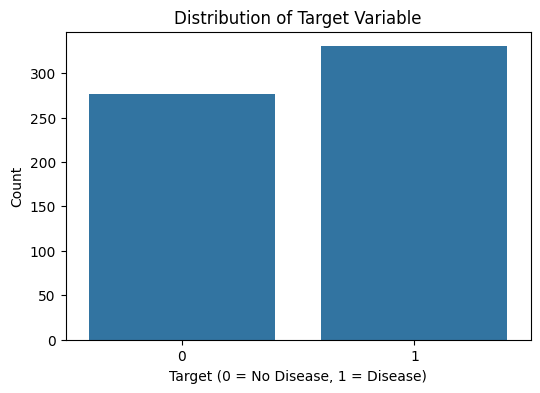

In [11]:
print("Distribution of 'target' variable:")
print(data['target'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=data)
plt.title('Distribution of Target Variable')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.show()

## Feature Distribution Analysis

### Subtask:
Visualize the distribution of key features, especially numerical ones, using histograms or box plots, and consider their relationship with the target variable using appropriate plots (e.g., count plots for categorical features).


**Reasoning**:
To visualize the distribution of numerical features, I will create histograms for 'age', 'chol', and 'thalach'. To visualize the distribution of categorical features and their relationship with the target variable, I will create count plots for 'sex', 'cp', 'ca', and 'thal', using 'target' as the hue.



Visualizing numerical feature distributions:


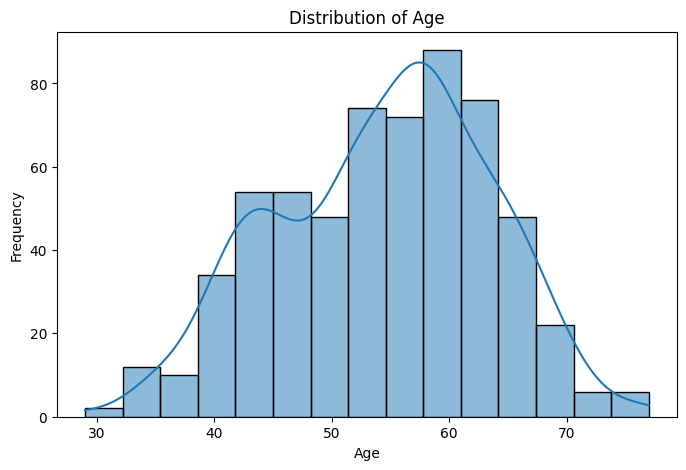

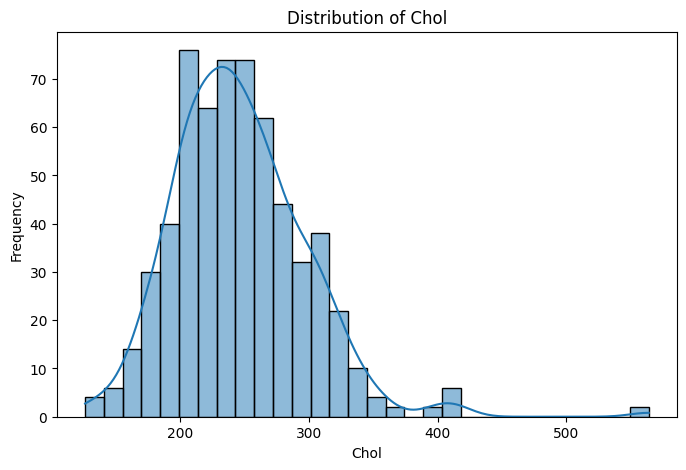

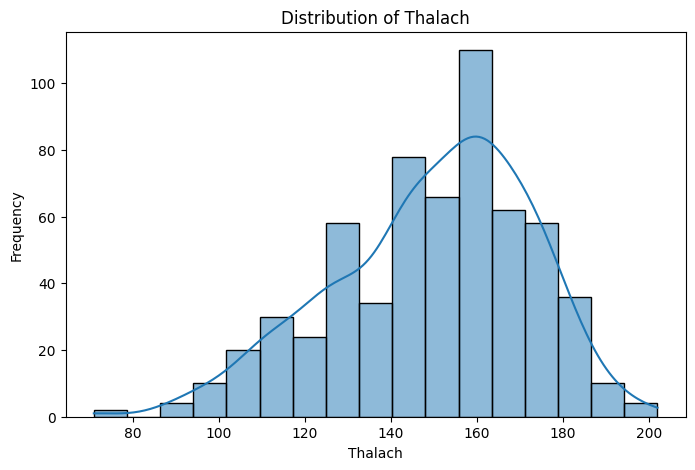


Visualizing categorical feature distributions and their relationship with the target variable:


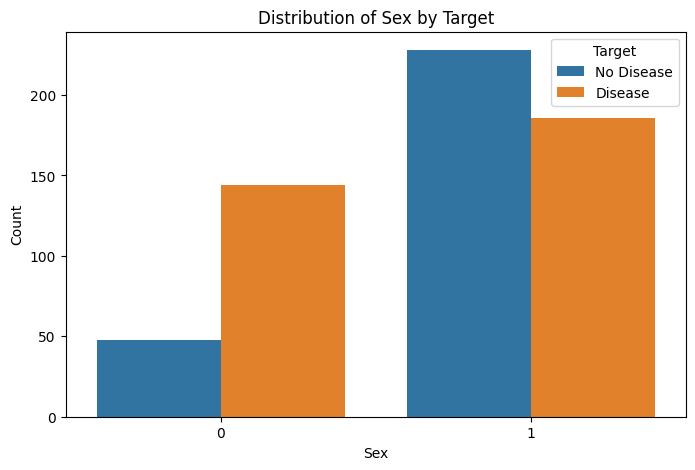

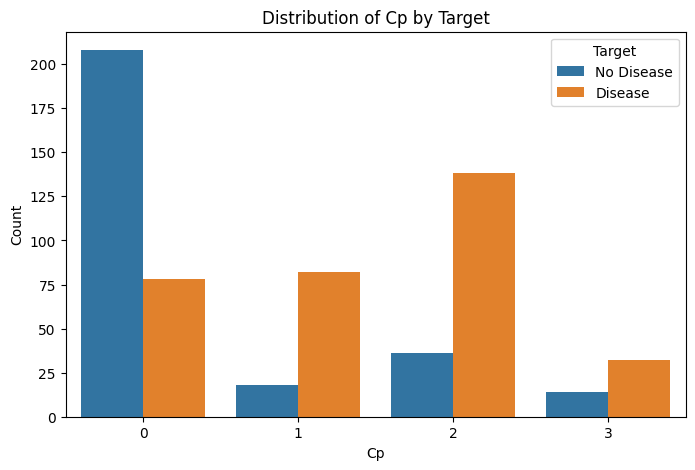

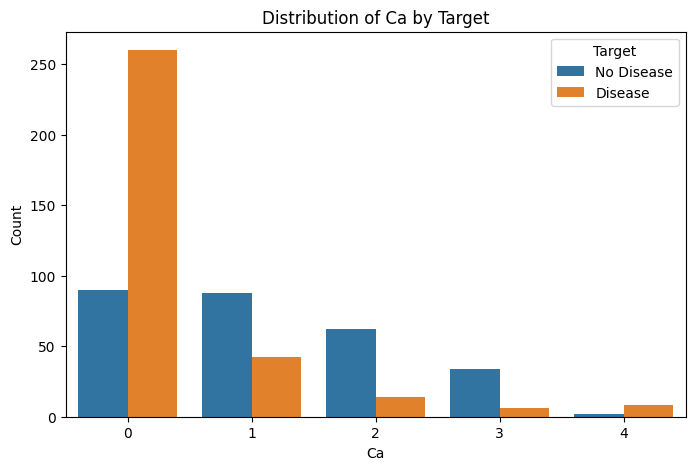

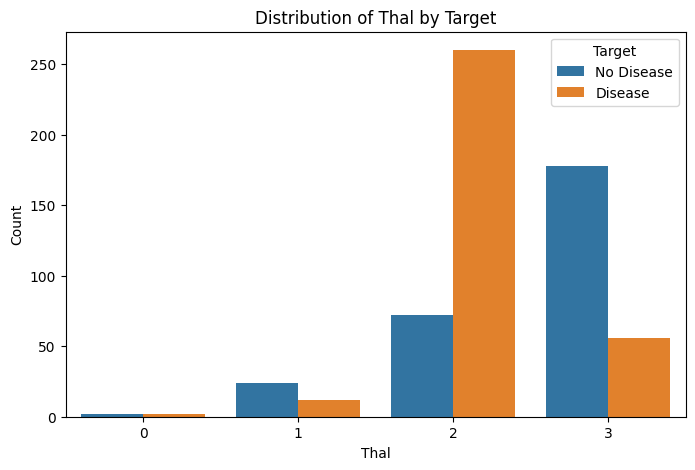

In [12]:
print("Visualizing numerical feature distributions:")
for feature in ['age', 'chol', 'thalach']:
    plt.figure(figsize=(8, 5))
    sns.histplot(data[feature], kde=True)
    plt.title(f'Distribution of {feature.capitalize()}')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Frequency')
    plt.show()

print("\nVisualizing categorical feature distributions and their relationship with the target variable:")
for feature in ['sex', 'cp', 'ca', 'thal']:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=feature, hue='target', data=data)
    plt.title(f'Distribution of {feature.capitalize()} by Target')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Count')
    plt.legend(title='Target', labels=['No Disease', 'Disease'])
    plt.show()

## Correlation Analysis

### Subtask:
Calculate and visualize the correlation matrix of the features to identify relationships between variables.


**Reasoning**:
To fulfill the subtask, I will first calculate the correlation matrix of the DataFrame `data` and then visualize it using a seaborn heatmap with annotations and a descriptive title.



Calculating and visualizing the correlation matrix...


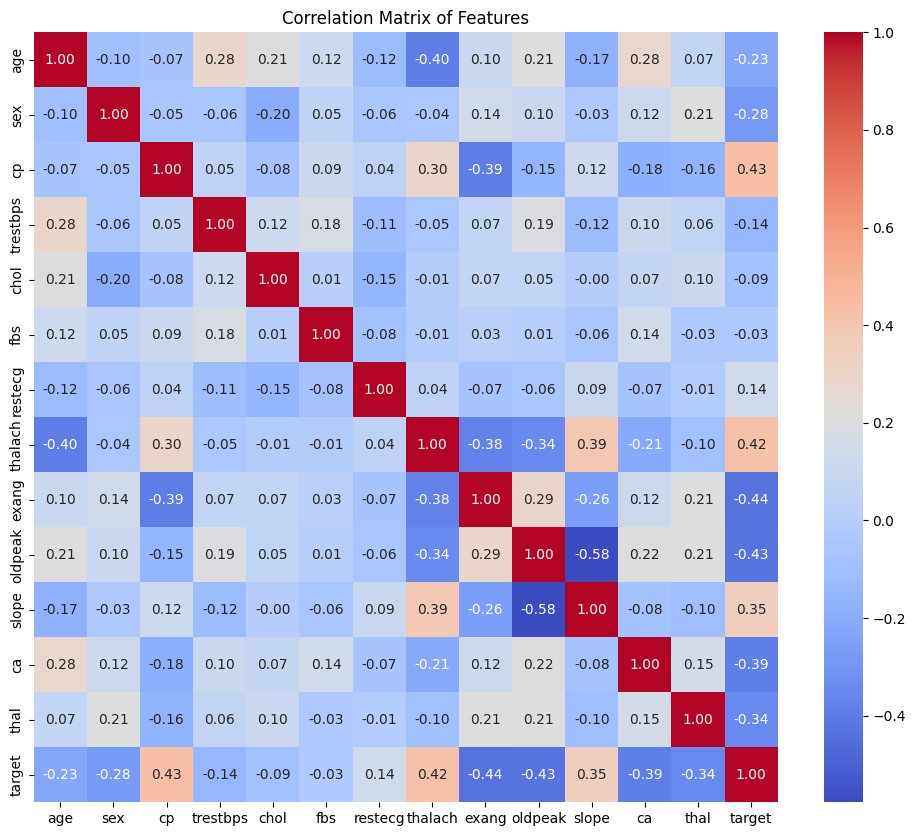

In [13]:
print("Calculating and visualizing the correlation matrix...")
correlation_matrix = data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

## Data Preprocessing

### Subtask:
Prepare the data for modeling by handling categorical features and splitting features (X) and target (y).


### Reasoning:
To prepare the data for modeling, I will first identify the categorical features requiring one-hot encoding: 'cp', 'restecg', 'slope', 'ca', and 'thal'. I will then apply `pd.get_dummies()` to these columns, creating new binary columns for each category. Finally, I will concatenate these new one-hot encoded columns with the original DataFrame and drop the initial categorical columns to avoid multicollinearity and ensure all features are numerical.

**Reasoning**:
To prepare the data for modeling, I will identify the categorical features and apply one-hot encoding using `pd.get_dummies()` to transform them into numerical representations, concatenating them with the original DataFrame and dropping the original columns.



In [14]:
categorical_features = ['cp', 'restecg', 'slope', 'ca', 'thal']
data_encoded = pd.get_dummies(data, columns=categorical_features, drop_first=True)

print("Shape of DataFrame after one-hot encoding:", data_encoded.shape)
print("First 5 rows of DataFrame after one-hot encoding:")
print(data_encoded.head())

Shape of DataFrame after one-hot encoding: (606, 23)
First 5 rows of DataFrame after one-hot encoding:
   age  sex  trestbps  chol  fbs  thalach  exang  oldpeak  target   cp_1  ...  \
0   48    1       130   256    1      150      1      0.0       0  False  ...   
1   61    1       148   203    0      161      0      0.0       0  False  ...   
2   44    0       118   242    0      149      0      0.3       1  False  ...   
3   47    1       110   275    0      118      1      1.0       0  False  ...   
4   56    1       120   193    0      162      0      1.9       1  False  ...   

   restecg_2  slope_1  slope_2   ca_1   ca_2   ca_3   ca_4  thal_1  thal_2  \
0      False    False     True  False   True  False  False   False   False   
1      False    False     True   True  False  False  False   False   False   
2      False     True    False   True  False  False  False   False    True   
3      False     True    False   True  False  False  False   False    True   
4      False     Tru

**Reasoning**:
Now that the categorical features have been one-hot encoded, I will separate the features (X) from the target variable (y) in the `data_encoded` DataFrame, and then print the shapes of X and y to confirm the split.



In [15]:
X = data_encoded.drop('target', axis=1)
y = data_encoded['target']

print("Shape of X (features):")
print(X.shape)
print("Shape of y (target):")
print(y.shape)

Shape of X (features):
(606, 22)
Shape of y (target):
(606,)


## Split Data into Training and Test Sets

### Subtask:
Divide the dataset into training and testing sets using `train_test_split` to prepare for model training and evaluation.


**Reasoning**:
To prepare the data for model training and evaluation, I will split the `X` and `y` datasets into training and testing sets using `train_test_split` with a test size of 0.2 and a `random_state` of 42. Afterward, I will print the shapes of the resulting sets to verify the split.



In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shapes of the split datasets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Shapes of the split datasets:
X_train shape: (484, 22)
X_test shape: (122, 22)
y_train shape: (484,)
y_test shape: (122,)


## Train Logistic Regression Model

### Subtask:
Initialize and train a Logistic Regression model on the training data.


**Reasoning**:
To initialize and train the Logistic Regression model, I will instantiate `LogisticRegression` and then use its `fit` method on the `X_train` and `y_train` datasets.



In [17]:
model = LogisticRegression(random_state=42, max_iter=200)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Reasoning**:
The previous code produced a `ConvergenceWarning` because the Logistic Regression model failed to converge within the specified `max_iter`. To address this, I will increase the `max_iter` parameter to a higher value (e.g., 1000) to allow the model more iterations to converge.



In [18]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Reasoning**:
The previous attempt to resolve the `ConvergenceWarning` by increasing `max_iter` was unsuccessful. As suggested by the warning, scaling the data is the next crucial step. I will apply `StandardScaler` to normalize the features before training the Logistic Regression model, which often helps the optimization algorithm converge.



In [19]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train Logistic Regression model with scaled data
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully with scaled data.")

Logistic Regression model trained successfully with scaled data.


## Predict on Test Data

### Subtask:
Make predictions on the test dataset using the trained Logistic Regression model.


**Reasoning**:
To make predictions on the test dataset, I will use the trained Logistic Regression model's `predict` method on the scaled test features, `X_test_scaled`, and store the results in `y_pred`.



In [20]:
y_pred = model.predict(X_test_scaled)

print("Predictions on test data:")
print(y_pred[:10]) # Displaying first 10 predictions

Predictions on test data:
[1 1 1 0 1 1 1 0 1 1]


## Evaluate Model Performance

### Subtask:
Evaluate the model's performance using the imported metrics: accuracy, precision, recall, F1-score, confusion matrix, ROC AUC score, and a classification report. Provide a clear printout of all these metrics.


**Reasoning**:
To evaluate the model's performance as requested, I will calculate and print accuracy, precision, recall, F1-score, confusion matrix, ROC AUC score, and the classification report using the `y_test` and `y_pred` values.



In [21]:
print("\n--- Model Evaluation ---")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

# Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

# F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")

# ROC AUC Score
roc_auc = roc_auc_score(y_test, y_pred)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Classification Report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)


--- Model Evaluation ---
Accuracy: 0.8443
Precision: 0.8630
Recall: 0.8750
F1-score: 0.8690
ROC AUC Score: 0.8375

Confusion Matrix:
[[40 10]
 [ 9 63]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        50
           1       0.86      0.88      0.87        72

    accuracy                           0.84       122
   macro avg       0.84      0.84      0.84       122
weighted avg       0.84      0.84      0.84       122



## Visualize Confusion Matrix

### Subtask:
Create a heatmap to visualize the confusion matrix for better interpretability of the model's classification performance. Ensure legends are provided.


### Reasoning:
To visualize the confusion matrix, I will create a heatmap using `seaborn.heatmap`. I will set `annot=True` to display the cell values and `fmt='d'` to format them as integers. Additionally, I will add a title 'Confusion Matrix' and label the x-axis as 'Predicted' and the y-axis as 'Actual' for better interpretability, finally displaying the plot with `plt.show()`.

**Reasoning**:
To visualize the confusion matrix as instructed, I will generate a heatmap using `seaborn.heatmap` with annotations, integer formatting, and appropriate labels.



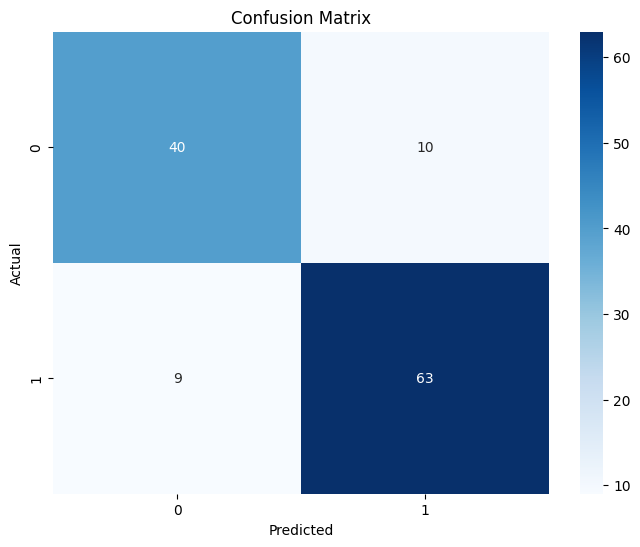

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Final Task

### Subtask:
Provide a summary of the data analysis, key insights from the exploratory analysis, and the overall performance of the Logistic Regression model, including its strengths and weaknesses.


## Summary:

### Data Analysis Key Findings
*   The dataset contains 606 entries and 14 features, with no missing values across any columns. Most features are integers, with 'oldpeak' being a float.
*   Descriptive statistics reveal varying ranges for numerical features; for example, 'age' ranges from 29 to 77, and 'cholesterol' (chol) from 126 to 564.
*   The 'target' variable, indicating the presence (1) or absence (0) of heart disease, shows a moderate imbalance with 330 instances of disease and 276 instances of no disease.
*   Feature distribution analysis, both numerical (e.g., 'age', 'chol', 'thalach') and categorical (e.g., 'sex', 'cp', 'ca', 'thal'), provided insights into their individual distributions and relationships with the target variable.
*   A correlation matrix was generated and visualized, illustrating the linear relationships between all features.
*   Data preprocessing involved one-hot encoding five categorical features ('cp', 'restecg', 'slope', 'ca', 'thal'), resulting in an expanded feature set of 22 columns for modeling.
*   The dataset was split into training (484 samples, 80%) and testing (122 samples, 20%) sets.
*   A Logistic Regression model was successfully trained on the scaled training data. Feature scaling using `StandardScaler` was crucial for model convergence.
*   The Logistic Regression model achieved the following performance metrics on the test set:
    *   Accuracy: 84.43%
    *   Precision: 86.30%
    *   Recall: 87.50%
    *   F1-score: 86.90%
    *   ROC AUC Score: 83.75%
*   The confusion matrix shows 63 true positives (correctly predicted disease), 40 true negatives (correctly predicted no disease), 10 false positives (predicted disease, but no disease), and 9 false negatives (predicted no disease, but disease present).

### Insights or Next Steps
*   The Logistic Regression model demonstrates good overall performance in predicting heart disease, with a strong balance between precision and recall, indicating its effectiveness in identifying true positive cases while keeping false positives relatively low.
*   To potentially enhance model performance, explore advanced machine learning algorithms (e.g., Random Forest, Gradient Boosting), perform feature engineering to create more informative features, or conduct hyperparameter tuning to optimize the current Logistic Regression model.


In [23]:
import pickle

# Define the filename for the saved model
model_filename_pkl = 'logistic_regression_model.pkl'

# Save the trained model to the file using pickle
with open(model_filename_pkl, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved successfully to {model_filename_pkl}")

Model saved successfully to logistic_regression_model.pkl
